In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
def load_cifar_batch(file_path):
    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    data = batch[b'data']          # (10000, 3072)
    labels = batch[b'labels']      # list of length 10000
    return data, labels


In [3]:
data_dir = "cifar-10-python/cifar-10-batches-py"

X_train = []
y_train = []

for i in range(1, 6):
    data, labels = load_cifar_batch(
        os.path.join(data_dir, f"data_batch_{i}")
    )
    X_train.append(data)
    y_train.extend(labels)

X_train = np.vstack(X_train)      # (50000, 3072)
y_train = np.array(y_train)


In [4]:
X_train.shape

(50000, 3072)

In [5]:
X_test , y_test = load_cifar_batch(os.path.join(data_dir, "test_batch"))
X_test = np.array(X_test)
y_test = np.array(y_test)

In [6]:
X_train.shape

(50000, 3072)

In [7]:
# (N, 3072) → (N, 3, 32, 32)
X_train = X_train.reshape(-1, 3, 32, 32)
X_test  = X_test.reshape(-1, 3, 32, 32)


In [8]:
#Normalizing
X_train = X_train.astype(np.float32)/255.0
X_test = X_test.astype(np.float32)/255.0

In [9]:
with open(os.path.join(data_dir, "batches.meta"), 'rb') as f:
    meta = pickle.load(f, encoding='bytes')

class_names = [c.decode('utf-8') for c in meta[b'label_names']]


In [10]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

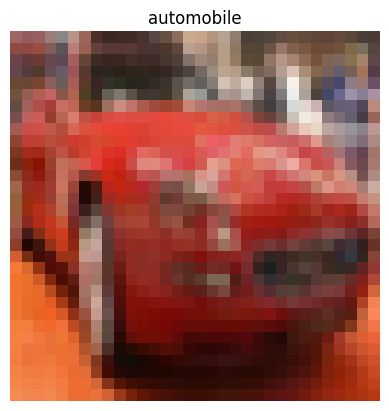

In [11]:
idx = 5
img = X_train[idx].transpose(1, 2, 0)  # CHW → HWC
label = y_train[idx]

plt.imshow(img)
plt.title(class_names[label])
plt.axis("off")
plt.show()

In [12]:
print(X_train.min(), X_train.max())


0.0 1.0


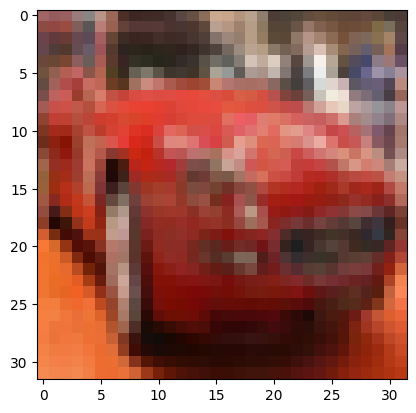

In [13]:
raw = X_train[idx] * 255
raw = raw.astype(np.uint8)
raw = raw.transpose(1, 2, 0)

plt.imshow(raw)
plt.show()


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split( X_train, y_train,test_size=0.1, random_state=42,stratify=y_train)

In [15]:
class CIFAR10Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [16]:
train_ds = CIFAR10Dataset(X_train, y_train)
val_ds   = CIFAR10Dataset(X_val, y_val)
test_ds  = CIFAR10Dataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)


In [17]:
x, y = next(iter(train_loader))
print(x.shape, y.shape)


torch.Size([64, 3, 32, 32]) torch.Size([64])


In [18]:
#Creating basline for training

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [20]:
class BaseCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)


    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # (B, 32, 16, 16)
        x = self.pool(F.relu(self.conv2(x)))   # (B, 64, 8, 8)
        x = self.pool(F.relu(self.conv3(x)))   # (B, 128, 4, 4)

        x = x.view(x.size(0), -1)               # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)                         # Logits (NO softmax)

        return x


In [21]:
model = BaseCNN()
x, y = next(iter(train_loader))
out = model(x)

print(out.shape)


torch.Size([64, 10])


In [22]:
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

model = BaseCNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [23]:
def accuracy_fn(outputs, targets):
    preds = outputs.argmax(dim=1)
    return (preds == targets).float().mean()


In [24]:
EPOCHS = 12

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model.train()
    train_loss, train_acc = 0.0, 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc  += accuracy_fn(outputs, y).item()

    train_loss /= len(train_loader)
    train_acc  /= len(train_loader)

    # ---- VALIDATION ----
    model.eval()
    val_loss, val_acc = 0.0, 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()
            val_acc  += accuracy_fn(outputs, y).item()

    val_loss /= len(val_loader)
    val_acc  /= len(val_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
    )


Epoch 1/12 | Train Loss: 1.6226 Acc: 0.3995 | Val Loss: 1.3063 Acc: 0.5281
Epoch 2/12 | Train Loss: 1.2611 Acc: 0.5458 | Val Loss: 1.1166 Acc: 0.5884
Epoch 3/12 | Train Loss: 1.0800 Acc: 0.6154 | Val Loss: 0.9698 Acc: 0.6541
Epoch 4/12 | Train Loss: 0.9598 Acc: 0.6616 | Val Loss: 0.9117 Acc: 0.6818
Epoch 5/12 | Train Loss: 0.8618 Acc: 0.6948 | Val Loss: 0.8461 Acc: 0.7011
Epoch 6/12 | Train Loss: 0.7730 Acc: 0.7273 | Val Loss: 0.8262 Acc: 0.7091
Epoch 7/12 | Train Loss: 0.7102 Acc: 0.7497 | Val Loss: 0.8160 Acc: 0.7156
Epoch 8/12 | Train Loss: 0.6540 Acc: 0.7683 | Val Loss: 0.7454 Acc: 0.7385
Epoch 9/12 | Train Loss: 0.6032 Acc: 0.7871 | Val Loss: 0.8109 Acc: 0.7328
Epoch 10/12 | Train Loss: 0.5551 Acc: 0.8020 | Val Loss: 0.8201 Acc: 0.7255
Epoch 11/12 | Train Loss: 0.5072 Acc: 0.8188 | Val Loss: 0.8003 Acc: 0.7352
Epoch 12/12 | Train Loss: 0.4693 Acc: 0.8312 | Val Loss: 0.8329 Acc: 0.7334


In [24]:
model.eval()

BaseCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [24]:
all_logits = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)

        all_logits.append(logits.cpu())
        all_labels.append(y)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)


In [25]:
probs = torch.softmax(all_logits, dim=1)

In [26]:
confidence, predictions = probs.max(dim=1)

In [27]:
failure_labels = (predictions != all_labels).long() #Failure 

In [28]:
print("Failure rate:", failure_labels.float().mean().item())
print("Avg confidence (correct):", confidence[failure_labels == 0].mean().item())
print("Avg confidence (wrong):", confidence[failure_labels == 1].mean().item())


Failure rate: 0.899399995803833
Avg confidence (correct): 0.10827349126338959
Avg confidence (wrong): 0.10834359377622604


In [29]:
torch.save({
    "model_state": model.state_dict(),
    "logits": all_logits,
    "labels": all_labels,
    "confidence": confidence,
    "failure_labels": failure_labels
}, "step1_outputs.pt")


In [30]:
import torch
#high entropy = model is confused 
entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)


In [31]:
entropy

tensor([2.3015, 2.3019, 2.3015,  ..., 2.3014, 2.3017, 2.3016])

In [32]:
print("Entropy (correct):", entropy[failure_labels == 0].mean().item())
print("Entropy (wrong):", entropy[failure_labels == 1].mean().item())

Entropy (correct): 2.3015928268432617
Entropy (wrong): 2.3015713691711426


## Selective Prediction -> Failure Aware Decision 

In [33]:
threshold = entropy.mean() + entropy.std() #Reject prediction with high entropy

In [34]:
threshold

tensor(2.3017)

In [35]:
entropy.mean()

tensor(2.3016)

In [36]:
#Apply Selective Prediction
accepted = entropy <= threshold
rejected = entropy > threshold

In [37]:
coverage = accepted.float().mean().item() #Coverage : how many sample are accepted 
#Seletive Accuracy :  accuracy on selective samples from coverage

selective_accuracy = (
    (predictions[accepted] == all_labels[accepted]).float().mean().item()
)

In [38]:
selective_accuracy

0.0975147932767868

In [39]:
coverage

0.8450000286102295

## Monto Carlo Dropout 

In [40]:
class BaseCNN_MC(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)      # IMPORTANT
        x = self.fc2(x)
        return x

In [41]:
model = BaseCNN_MC().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


In [42]:
model.train()

BaseCNN_MC(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [76]:
import torch
import torch.nn as nn
import torch.optim as optim

# ----- Setup -----
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BaseCNN_MC().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 12
best_val_acc = 0   # ---- ADD BEFORE TRAINING ----


# ----- Training Loop -----
for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_loss = 0
    train_acc = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += (outputs.argmax(1) == y).float().mean().item()

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)


    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()
            val_acc += (outputs.argmax(1) == y).float().mean().item()

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)


    # -------- SAVE BEST MODEL --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")


    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
    )


print("Training Finished")
print("Best Validation Accuracy:", best_val_acc)

Epoch 1/12 | Train Loss: 1.5945 Acc: 0.4152 | Val Loss: 1.2939 Acc: 0.5384
Epoch 2/12 | Train Loss: 1.2380 Acc: 0.5562 | Val Loss: 1.0878 Acc: 0.6185
Epoch 3/12 | Train Loss: 1.0630 Acc: 0.6225 | Val Loss: 1.0786 Acc: 0.6228
Epoch 4/12 | Train Loss: 0.9431 Acc: 0.6694 | Val Loss: 0.9319 Acc: 0.6748
Epoch 5/12 | Train Loss: 0.8505 Acc: 0.7001 | Val Loss: 0.8425 Acc: 0.7025
Epoch 6/12 | Train Loss: 0.7642 Acc: 0.7338 | Val Loss: 0.9295 Acc: 0.6810
Epoch 7/12 | Train Loss: 0.6997 Acc: 0.7559 | Val Loss: 0.7606 Acc: 0.7332
Epoch 8/12 | Train Loss: 0.6391 Acc: 0.7766 | Val Loss: 0.7440 Acc: 0.7427
Epoch 9/12 | Train Loss: 0.5889 Acc: 0.7908 | Val Loss: 0.7229 Acc: 0.7486
Epoch 10/12 | Train Loss: 0.5319 Acc: 0.8122 | Val Loss: 0.7214 Acc: 0.7551
Epoch 11/12 | Train Loss: 0.4918 Acc: 0.8242 | Val Loss: 0.7326 Acc: 0.7591
Epoch 12/12 | Train Loss: 0.4445 Acc: 0.8404 | Val Loss: 0.7674 Acc: 0.7518
Training Finished
Best Validation Accuracy: 0.7590981012658228


In [43]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

BaseCNN_MC(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [44]:
# Monto Carlo inference : run multiple forward passes

In [45]:
all_logits = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)

        all_logits.append(logits.cpu())
        all_labels.append(y)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

probs = torch.softmax(all_logits, dim=1)
predictions = probs.argmax(dim=1)

failure_labels = (predictions != all_labels).long()

In [46]:
# Enable dropout at inference
def enable_mc_dropout(model):
    for m in model.modules():
        if isinstance(m , nn.Dropout):
            m.train()

In [47]:
enable_mc_dropout(model)

In [48]:
T = 20
all_mc_probs = []

with torch.no_grad():
    for x, _ in val_loader:
        x = x.to(device)

        batch_mc = []

        for _ in range(T):
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            batch_mc.append(probs)

        batch_mc = torch.stack(batch_mc)
        all_mc_probs.append(batch_mc)

all_mc_probs = torch.cat(all_mc_probs, dim=1)  # (T, 5000, 10)

In [49]:
#compute mc Entropy
mean_probs = all_mc_probs.mean(dim=0)

entropy_mc = -torch.sum(
    mean_probs * torch.log(mean_probs + 1e-8),
    dim=1
)

In [50]:
print("Entropy wrong:", entropy_mc[failure_labels == 1].mean().item())
print("Entropy correct:", entropy_mc[failure_labels == 0].mean().item())

Entropy wrong: 1.050734281539917
Entropy correct: 0.4807131290435791


In [51]:
#Risk Coverage Curve
#Lower Entropy = Safer prediciton
sorted_indices = torch.argsort(entropy_mc)

In [52]:
coverages = []
accuracies = []

N = len(entropy_mc)

for frac in torch.linspace(0.5, 1.0, steps=20):  
    k = int(frac * N)

    selected = sorted_indices[:k]   # keep lowest entropy samples
    
    acc = (predictions[selected] == all_labels[selected]).float().mean().item()
    
    coverages.append(frac.item())
    accuracies.append(acc)

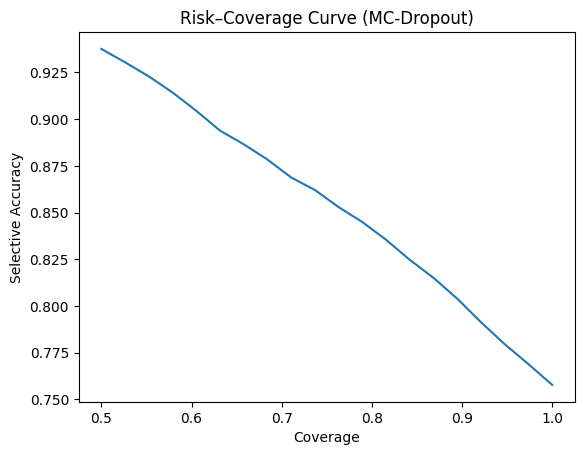

In [53]:
import matplotlib.pyplot as plt

plt.plot(coverages, accuracies)
plt.xlabel("Coverage")
plt.ylabel("Selective Accuracy")
plt.title("Risk–Coverage Curve (MC-Dropout)")
plt.show()

In [54]:
base_acc = (predictions == all_labels).float().mean().item()
print("Base Accuracy:", base_acc)

Base Accuracy: 0.7577999830245972


In [55]:
k = int(0.7 * N)
selected = sorted_indices[:k]
selective_acc = (predictions[selected] == all_labels[selected]).float().mean().item()

print("Selective Accuracy at 70% coverage:", selective_acc)

Selective Accuracy at 70% coverage: 0.871999979019165


In [56]:
# Selective accuracy >> base accuracy

### Build Failure Prediction Head 

In [57]:
# Instead of: "Reject if entropy > threshold"
# We train a model that learns: "Given logits + uncertainty signals → predict probability of failure"
# This becomes a Failure Prediction Head.

In [58]:
# Extract Failue Features
# create a feature matrix for each validation sample compute : max confidence , entropy , varaince , logit margin (top1-top2)

In [59]:
probs = torch.softmax(all_logits, dim=1)

In [60]:
#Logit margin
top2_probs, _ = torch.topk(probs, k=2, dim=1)
margin = top2_probs[:, 0] - top2_probs[:, 1]

#variance
variance = all_mc_probs.var(dim=0).mean(dim=1)

In [61]:
confidence = probs.max(dim=1).values

features = torch.stack([
    confidence,
    entropy_mc,
    variance,
    margin
], dim=1)

print(features.shape)   # should be [5000, 4]

torch.Size([5000, 4])


In [62]:
features

tensor([[9.6335e-01, 2.4938e-01, 7.7661e-04, 9.2920e-01],
        [2.4924e-01, 1.6124e+00, 5.1689e-03, 4.9302e-03],
        [5.1413e-01, 7.7415e-01, 3.5521e-03, 3.7059e-02],
        ...,
        [5.8560e-01, 1.3987e+00, 4.0109e-03, 4.3625e-01],
        [9.6537e-01, 2.1474e-01, 9.5760e-05, 9.4047e-01],
        [6.7633e-01, 1.1300e+00, 8.0328e-03, 4.4854e-01]])

In [63]:
class FailureHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

In [64]:
failure_model = FailureHead().to(device)

criterion_f = nn.BCEWithLogitsLoss()
optimizer_f = torch.optim.Adam(failure_model.parameters(), lr=1e-3)

X_f = features.to(device)
y_f = failure_labels.float().unsqueeze(1).to(device)

EPOCHS = 50

for epoch in range(EPOCHS):
    failure_model.train()

    optimizer_f.zero_grad()
    logits_f = failure_model(X_f)
    loss_f = criterion_f(logits_f, y_f)

    loss_f.backward()
    optimizer_f.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss_f.item():.4f}")

Epoch 0 Loss: 0.7159
Epoch 10 Loss: 0.6944
Epoch 20 Loss: 0.6747
Epoch 30 Loss: 0.6566
Epoch 40 Loss: 0.6400


In [65]:
from sklearn.metrics import roc_auc_score

failure_model.eval()

with torch.no_grad():
    logits_f = failure_model(X_f)
    probs_f = torch.sigmoid(logits_f).cpu().numpy()

auc = roc_auc_score(y_f.cpu().numpy(), probs_f)

print("Failure Prediction ROC-AUC:", auc)

Failure Prediction ROC-AUC: 0.8150199663112766


In [66]:
#now instead of entropy use failure model 
# if failure probability > threshold -> Reject
# else accept prediction 

In [67]:
threshold = 0.5

with torch.no_grad():
    failure_logits = failure_model(features.to(device))
    failure_probs = torch.sigmoid(failure_logits)

accepted = failure_probs.squeeze() < threshold

In [68]:
#Evaluate Selective accuracy
accepted_idx = accepted.cpu()

selective_acc = (
    (predictions[accepted_idx] == all_labels[accepted_idx])
    .float()
    .mean()
    .item()
)

coverage = accepted_idx.float().mean().item()

print("Coverage:", coverage)
print("Selective Accuracy:", selective_acc)

Coverage: 1.0
Selective Accuracy: 0.7577999830245972


In [69]:
#Visualization

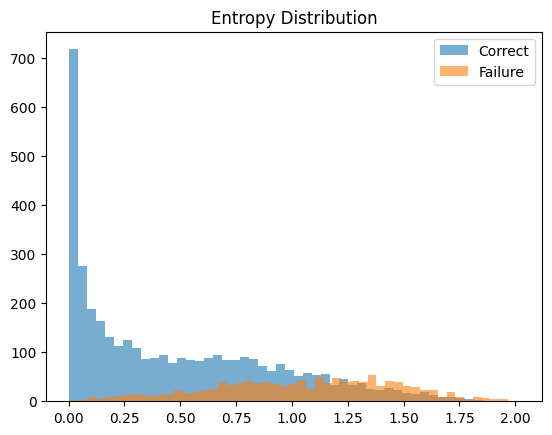

In [70]:
import matplotlib.pyplot as plt

plt.hist(entropy_mc[failure_labels==0], bins=50, alpha=0.6, label="Correct")
plt.hist(entropy_mc[failure_labels==1], bins=50, alpha=0.6, label="Failure")

plt.legend()
plt.title("Entropy Distribution")
plt.show()

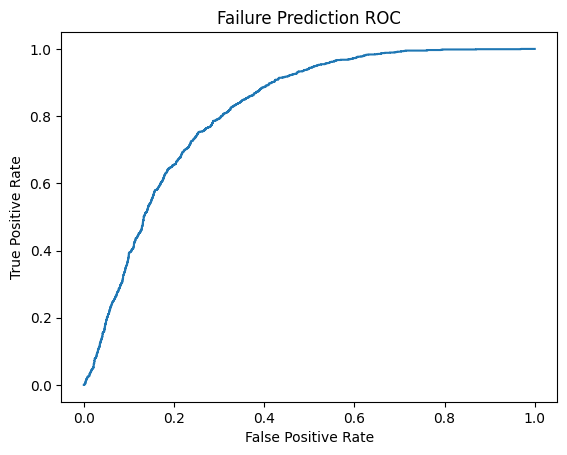

In [71]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_f.cpu().numpy(), probs_f)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Failure Prediction ROC")
plt.show()

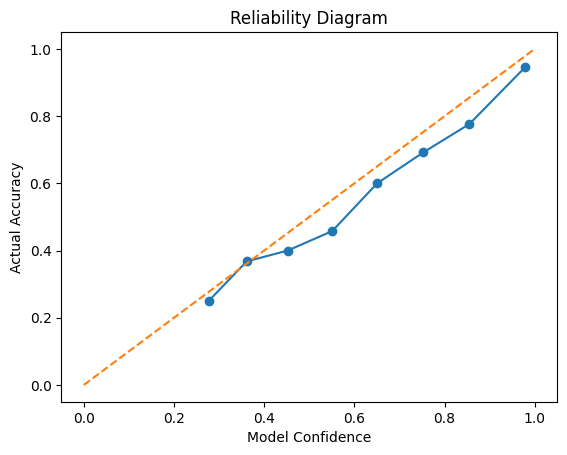

In [74]:
# Reliability Diagram (Calibration Curve)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

confidence = probs.max(dim=1).values.cpu().numpy()
correct = (predictions == all_labels).cpu().numpy()

prob_true, prob_pred = calibration_curve(correct, confidence, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')

plt.xlabel("Model Confidence")
plt.ylabel("Actual Accuracy")
plt.title("Reliability Diagram")
plt.show()

C:\Users\dhruv\AppData\Local\Temp\ipykernel_17168\3581812733.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_rate = df.groupby("bin")["error"].mean()
C:\Users\dhruv\AppData\Local\Temp\ipykernel_17168\3581812733.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_avg = df.groupby("bin")["confidence"].mean()


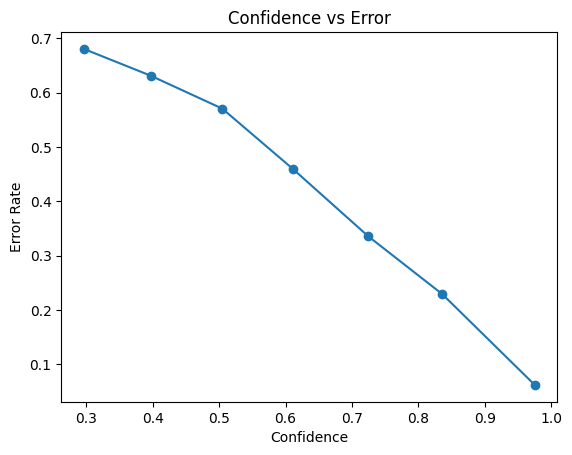

In [77]:
import pandas as pd

df = pd.DataFrame({
    "confidence": confidence,
    "correct": (predictions == all_labels).cpu().numpy()
})

df["error"] = 1 - df["correct"]

bins = np.linspace(0,1,10)
df["bin"] = pd.cut(df["confidence"], bins)

error_rate = df.groupby("bin")["error"].mean()
conf_avg = df.groupby("bin")["confidence"].mean()

plt.plot(conf_avg, error_rate, marker='o')

plt.xlabel("Confidence")
plt.ylabel("Error Rate")
plt.title("Confidence vs Error")
plt.show()

In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FailureNet:
    def __init__(self, cnn_model, failure_head, mc_passes=20, threshold=0.5, device="cpu"):

        self.cnn = cnn_model
        self.failure_head = failure_head
        self.mc_passes = mc_passes
        self.threshold = threshold
        self.device = device

        self.cnn.to(device)
        self.failure_head.to(device)

        self.cnn.eval()
        self.failure_head.eval()

    def enable_mc_dropout(self):
        for m in self.cnn.modules():
            if isinstance(m, nn.Dropout):
                m.train()

    def compute_uncertainty(self, x):
        mc_probs = []
        self.enable_mc_dropout()

        with torch.no_grad():
            for _ in range(self.mc_passes):
                logits = self.cnn(x)
                probs = torch.softmax(logits, dim=1)
                mc_probs.append(probs)
                
        mc_probs = torch.stack(mc_probs)   # (T, B, C)
        mean_probs = mc_probs.mean(dim=0)

        entropy = -torch.sum(mean_probs * torch.log(mean_probs + 1e-8),dim=1)
        variance = mc_probs.var(dim=0).mean(dim=1)
        confidence = mean_probs.max(dim=1).values

        top2_probs, _ = torch.topk(mean_probs, k=2, dim=1)
        margin = top2_probs[:, 0] - top2_probs[:, 1]

        features = torch.stack([
            confidence,
            entropy,
            variance,
            margin
        ], dim=1)

        return mean_probs, features

    def predict(self, x):
        x = x.to(self.device)
        mean_probs, features = self.compute_uncertainty(x)
        with torch.no_grad():
            failure_logits = self.failure_head(features)
            failure_prob = torch.sigmoid(failure_logits)

        predictions = mean_probs.argmax(dim=1)
        results = []

        for i in range(len(predictions)):
            decision = "ACCEPT"
            if failure_prob[i] > self.threshold:
                decision = "REJECT"
            results.append({
                "prediction": predictions[i].item(),
                "confidence": mean_probs[i].max().item(),
                "failure_probability": failure_prob[i].item(),
                "decision": decision
            })

        return results

In [73]:
# Think of it like a self-driving car system.
# Camera → object detector → risk analyzer → decision

# Your FailureNet is similar:
# Image → CNN → uncertainty analyzer → failure predictor → decision

In [81]:
torch.save(failure_model.state_dict(), "failure_head.pth")

In [87]:
cnn_model = BaseCNN_MC()
failure_head = FailureHead()

In [88]:
cnn_model.load_state_dict(torch.load("best_model.pth"))
failure_head.load_state_dict(torch.load("failure_head.pth"))

<All keys matched successfully>

In [89]:
failurenet = FailureNet(
    cnn_model,
    failure_head,
    mc_passes=20,
    threshold=0.5,
    device=device
)

In [90]:
results = failurenet.predict(x)

print(results)

[{'prediction': 1, 'confidence': 0.9999490976333618, 'failure_probability': 0.41514289379119873, 'decision': 'ACCEPT'}, {'prediction': 3, 'confidence': 0.7395268082618713, 'failure_probability': 0.45193910598754883, 'decision': 'ACCEPT'}, {'prediction': 8, 'confidence': 0.9896160364151001, 'failure_probability': 0.41861531138420105, 'decision': 'ACCEPT'}, {'prediction': 6, 'confidence': 0.8575448989868164, 'failure_probability': 0.4477822780609131, 'decision': 'ACCEPT'}, {'prediction': 4, 'confidence': 0.5591198205947876, 'failure_probability': 0.46955564618110657, 'decision': 'ACCEPT'}, {'prediction': 7, 'confidence': 0.5647958517074585, 'failure_probability': 0.45462295413017273, 'decision': 'ACCEPT'}, {'prediction': 2, 'confidence': 0.940750241279602, 'failure_probability': 0.433485746383667, 'decision': 'ACCEPT'}, {'prediction': 3, 'confidence': 0.6130124926567078, 'failure_probability': 0.46105873584747314, 'decision': 'ACCEPT'}]


In [ ]:
# Input Image
#      ↓
# CNN Classifier
#      ↓
# Monte Carlo Dropout (20 runs)
#      ↓
# Uncertainty Signals
#    • Confidence
#    • Entropy
#    • Variance
#    • Margin
#      ↓
# Failure Prediction Head
#      ↓
# Failure Probability
#      ↓
# Decision
#    ACCEPT / REJECT

In [91]:
classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

for i, r in enumerate(results):
    pred_class = classes[r["prediction"]]

    print(f"""
Sample {i+1}
--------------------------------
Prediction           : {pred_class}
Confidence           : {r['confidence']:.3f}
Failure Probability  : {r['failure_probability']:.3f}
Decision             : {r['decision']}
""")


Sample 1
--------------------------------
Prediction           : automobile
Confidence           : 1.000
Failure Probability  : 0.415
Decision             : ACCEPT


Sample 2
--------------------------------
Prediction           : cat
Confidence           : 0.740
Failure Probability  : 0.452
Decision             : ACCEPT


Sample 3
--------------------------------
Prediction           : ship
Confidence           : 0.990
Failure Probability  : 0.419
Decision             : ACCEPT


Sample 4
--------------------------------
Prediction           : frog
Confidence           : 0.858
Failure Probability  : 0.448
Decision             : ACCEPT


Sample 5
--------------------------------
Prediction           : deer
Confidence           : 0.559
Failure Probability  : 0.470
Decision             : ACCEPT


Sample 6
--------------------------------
Prediction           : horse
Confidence           : 0.565
Failure Probability  : 0.455
Decision             : ACCEPT


Sample 7
------------------------